# Data Analysis

In [1]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## Single Stream Str

In [2]:
single_folder_path = '../infra/reports/single_2026-04-13T14:33:27.878334'

### CPU

In [3]:
ds_scpu = pd.read_csv(f'{single_folder_path}/cpu.csv')

ds_scpu['timestamp'] = ds_scpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
ds_scpu['cpu_mean']  = ds_scpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

ds_scpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1318.000000,1318.000000,1318.000000,1318.000000,1318.000000
mean,7.908574,8.978073,10.960395,7.491351,8.834598
std,13.055917,14.663132,14.370896,12.788021,9.395413
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,3.500000
50%,0.000000,0.000000,1.000000,0.000000,5.625000
75%,14.000000,15.000000,18.950000,13.900000,9.112500
max,79.000000,99.000000,83.200000,80.200000,37.325000


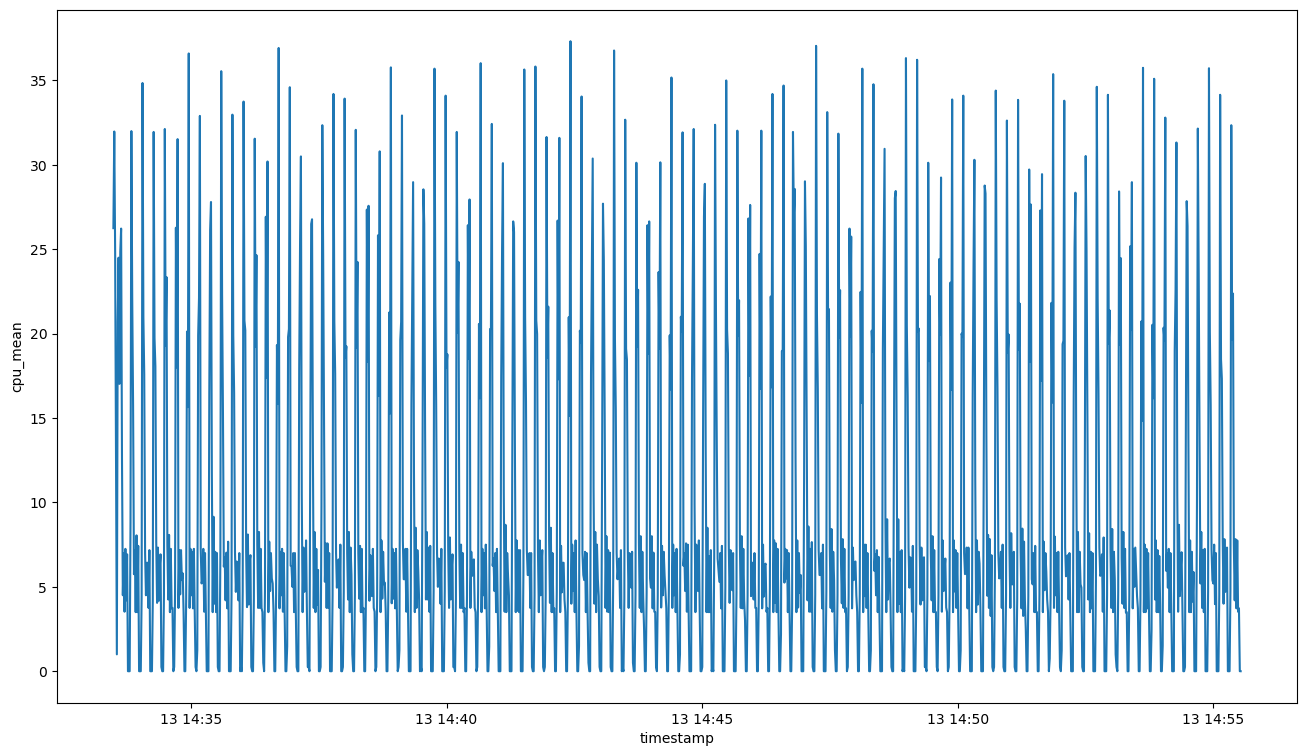

In [4]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=ds_scpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

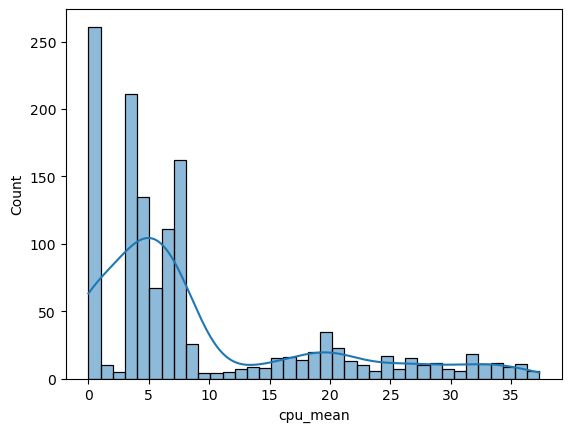

In [5]:
sns.histplot(data=ds_scpu, x="cpu_mean", kde=True)
plt.show()

### RAM

In [8]:
ds_sram = pd.read_csv(f'{single_folder_path}/mem.csv')
ds_sram['timestamp'] = ds_sram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
ds_sram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-13 14:33:27.879057,17002643456,16449748992,552894464,3.3,15847211008,732020736,192741376,40435712,680493056
1,2026-04-13 14:33:28.880595,17002643456,16409346048,593297408,3.5,15804170240,766590976,193740800,40435712,682999808
2,2026-04-13 14:33:29.911462,17002643456,16295116800,707526656,4.2,15689940992,836681728,193740800,40435712,682999808
3,2026-04-13 14:33:30.922719,17002643456,16257286144,745357312,4.4,15651979264,871317504,193740800,40435712,683130880
4,2026-04-13 14:33:31.923070,17002643456,16100032512,902610944,5.3,15448866816,1001701376,239583232,40435712,729284608


### Predict

In [9]:
from pandas import json_normalize
import json

with open(f'{single_folder_path}/metrics.json') as f:
    single_data = json.load(f)

load_model_duration = datetime.fromisoformat(single_data['load_model_final']) - datetime.fromisoformat(single_data['load_model_start'])
    
rows = []
for animal, v1 in single_data['animals'].items():
    row = {
        'pid': single_data['pid'],
        'load_model_start': datetime.fromisoformat(single_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(single_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

ds_smetrics_v0 = pd.DataFrame.from_dict(rows)[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
ds_smetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time
0,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,1,2026-04-13 14:33:34.903341,2026-04-13 14:33:44.593147,2026-04-13 14:33:37.252125,2026-04-13 14:33:38.130005,2026-04-13 14:33:45.255225
1,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,1,2026-04-13 14:33:34.903341,2026-04-13 14:33:44.593147,2026-04-13 14:33:37.252125,2026-04-13 14:33:38.130005,2026-04-13 14:33:45.255225
2,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,2,2026-04-13 14:33:48.255331,2026-04-13 14:33:57.779617,2026-04-13 14:33:50.437910,2026-04-13 14:33:51.309604,2026-04-13 14:33:58.419962
3,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,2,2026-04-13 14:33:48.255331,2026-04-13 14:33:57.779617,2026-04-13 14:33:50.437910,2026-04-13 14:33:51.309604,2026-04-13 14:33:58.419962
4,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,3,2026-04-13 14:34:01.421830,2026-04-13 14:34:10.929599,2026-04-13 14:34:03.609023,2026-04-13 14:34:04.485214,2026-04-13 14:34:11.571438


In [10]:
ds_smetrics_v0['weight_prediction_dur'] = ds_smetrics_v0['weight_prediction_final'] - ds_smetrics_v0['weight_prediction_start']
ds_smetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,weight_prediction_dur
0,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,1,2026-04-13 14:33:34.903341,2026-04-13 14:33:44.593147,2026-04-13 14:33:37.252125,2026-04-13 14:33:38.130005,2026-04-13 14:33:45.255225,0 days 00:00:00.877880
1,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,1,2026-04-13 14:33:34.903341,2026-04-13 14:33:44.593147,2026-04-13 14:33:37.252125,2026-04-13 14:33:38.130005,2026-04-13 14:33:45.255225,0 days 00:00:00.877880
2,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,2,2026-04-13 14:33:48.255331,2026-04-13 14:33:57.779617,2026-04-13 14:33:50.437910,2026-04-13 14:33:51.309604,2026-04-13 14:33:58.419962,0 days 00:00:00.871694
3,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,2,2026-04-13 14:33:48.255331,2026-04-13 14:33:57.779617,2026-04-13 14:33:50.437910,2026-04-13 14:33:51.309604,2026-04-13 14:33:58.419962,0 days 00:00:00.871694
4,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,3,2026-04-13 14:34:01.421830,2026-04-13 14:34:10.929599,2026-04-13 14:34:03.609023,2026-04-13 14:34:04.485214,2026-04-13 14:34:11.571438,0 days 00:00:00.876191


In [11]:
by_animal_dict = []

for animal, by_animal in ds_smetrics_v0.groupby('animal'):
    # .max() return the most recent date   
    by_animal_lead_time = by_animal['display_time'].max() - by_animal['first_image_capture_time'].iloc[0]
    by_animal_processing_delay = by_animal['weight_prediction_dur'].sum()
    by_animal_latency = by_animal['display_time'].max() - by_animal['last_image_capture_time'].max()
    
    by_animal_dict.append({
        'animal': animal,
        'by_animal_lead_time':by_animal_lead_time,
        'by_animal_processing_delay':by_animal_processing_delay,
        'by_animal_latency':by_animal_latency,
    })

ds_smetrics_v1 = ds_smetrics_v0.merge(
    pd.DataFrame.from_records(by_animal_dict),
    on='animal'
)
ds_smetrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,1,2026-04-13 14:33:34.903341,2026-04-13 14:33:44.593147,2026-04-13 14:33:37.252125,2026-04-13 14:33:38.130005,2026-04-13 14:33:45.255225,0 days 00:00:00.877880,0 days 00:00:10.351884,0 days 00:00:01.755760,0 days 00:00:00.662078
1,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,1,2026-04-13 14:33:34.903341,2026-04-13 14:33:44.593147,2026-04-13 14:33:37.252125,2026-04-13 14:33:38.130005,2026-04-13 14:33:45.255225,0 days 00:00:00.877880,0 days 00:00:10.351884,0 days 00:00:01.755760,0 days 00:00:00.662078
2,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,2,2026-04-13 14:33:48.255331,2026-04-13 14:33:57.779617,2026-04-13 14:33:50.437910,2026-04-13 14:33:51.309604,2026-04-13 14:33:58.419962,0 days 00:00:00.871694,0 days 00:00:10.164631,0 days 00:00:01.743388,0 days 00:00:00.640345
3,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,2,2026-04-13 14:33:48.255331,2026-04-13 14:33:57.779617,2026-04-13 14:33:50.437910,2026-04-13 14:33:51.309604,2026-04-13 14:33:58.419962,0 days 00:00:00.871694,0 days 00:00:10.164631,0 days 00:00:01.743388,0 days 00:00:00.640345
4,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,3,2026-04-13 14:34:01.421830,2026-04-13 14:34:10.929599,2026-04-13 14:34:03.609023,2026-04-13 14:34:04.485214,2026-04-13 14:34:11.571438,0 days 00:00:00.876191,0 days 00:00:10.149608,0 days 00:00:01.752382,0 days 00:00:00.641839


In [12]:
collect_lead_time = ds_smetrics_v1['display_time'].max() - ds_smetrics_v1['first_image_capture_time'].min()
qtt = len(ds_smetrics_v1['animal'].unique())

ds_smetrics_v1['collect_lead_time'] = collect_lead_time
ds_smetrics_v1['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

ds_smetrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,1,2026-04-13 14:33:34.903341,2026-04-13 14:33:44.593147,2026-04-13 14:33:37.252125,2026-04-13 14:33:38.130005,2026-04-13 14:33:45.255225,0 days 00:00:00.877880,0 days 00:00:10.351884,0 days 00:00:01.755760,0 days 00:00:00.662078,0 days 00:21:54.810564,273.803702
1,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,1,2026-04-13 14:33:34.903341,2026-04-13 14:33:44.593147,2026-04-13 14:33:37.252125,2026-04-13 14:33:38.130005,2026-04-13 14:33:45.255225,0 days 00:00:00.877880,0 days 00:00:10.351884,0 days 00:00:01.755760,0 days 00:00:00.662078,0 days 00:21:54.810564,273.803702
2,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,2,2026-04-13 14:33:48.255331,2026-04-13 14:33:57.779617,2026-04-13 14:33:50.437910,2026-04-13 14:33:51.309604,2026-04-13 14:33:58.419962,0 days 00:00:00.871694,0 days 00:00:10.164631,0 days 00:00:01.743388,0 days 00:00:00.640345,0 days 00:21:54.810564,273.803702
3,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,2,2026-04-13 14:33:48.255331,2026-04-13 14:33:57.779617,2026-04-13 14:33:50.437910,2026-04-13 14:33:51.309604,2026-04-13 14:33:58.419962,0 days 00:00:00.871694,0 days 00:00:10.164631,0 days 00:00:01.743388,0 days 00:00:00.640345,0 days 00:21:54.810564,273.803702
4,single_2026-04-13T14:33:27.878334,2026-04-13 14:33:27.878829,2026-04-13 14:33:34.903218,0 days 00:00:07.024389,3,2026-04-13 14:34:01.421830,2026-04-13 14:34:10.929599,2026-04-13 14:34:03.609023,2026-04-13 14:34:04.485214,2026-04-13 14:34:11.571438,0 days 00:00:00.876191,0 days 00:00:10.149608,0 days 00:00:01.752382,0 days 00:00:00.641839,0 days 00:21:54.810564,273.803702


### Power

In [43]:
ds_spower = pd.read_csv(f'{single_folder_path}/single.csv')
ds_spower['timestamp'] = ds_spower['Datetime'].apply(lambda x: datetime.fromisoformat(x))
ds_spower.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-13T14:33:16.984033,0.0,5.1097,0.51940,2.6489,2026-04-13 14:33:16.984033
1,2026-04-13T14:33:17.997845,1.0,5.1098,0.51963,2.6501,2026-04-13 14:33:17.997845
2,2026-04-13T14:33:19.010984,2.0,5.1099,0.76211,3.8867,2026-04-13 14:33:19.010984
3,2026-04-13T14:33:19.979808,3.0,5.1100,0.77372,3.9537,2026-04-13 14:33:19.979808
4,2026-04-13T14:33:20.995662,4.0,5.1097,0.82810,4.2233,2026-04-13 14:33:20.995662


In [46]:
ds_spower = ds_spower.sort_values('timestamp')

# Time difference in hours
ds_spower['dt_hours'] = ds_spower['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
ds_spower['energy_Wh'] = ds_spower['Power[W]'] * ds_spower['dt_hours']

# Total energy
total_energy_Wh = ds_spower['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.4780771780854722
Total energy (kWh): 0.0014780771780854723


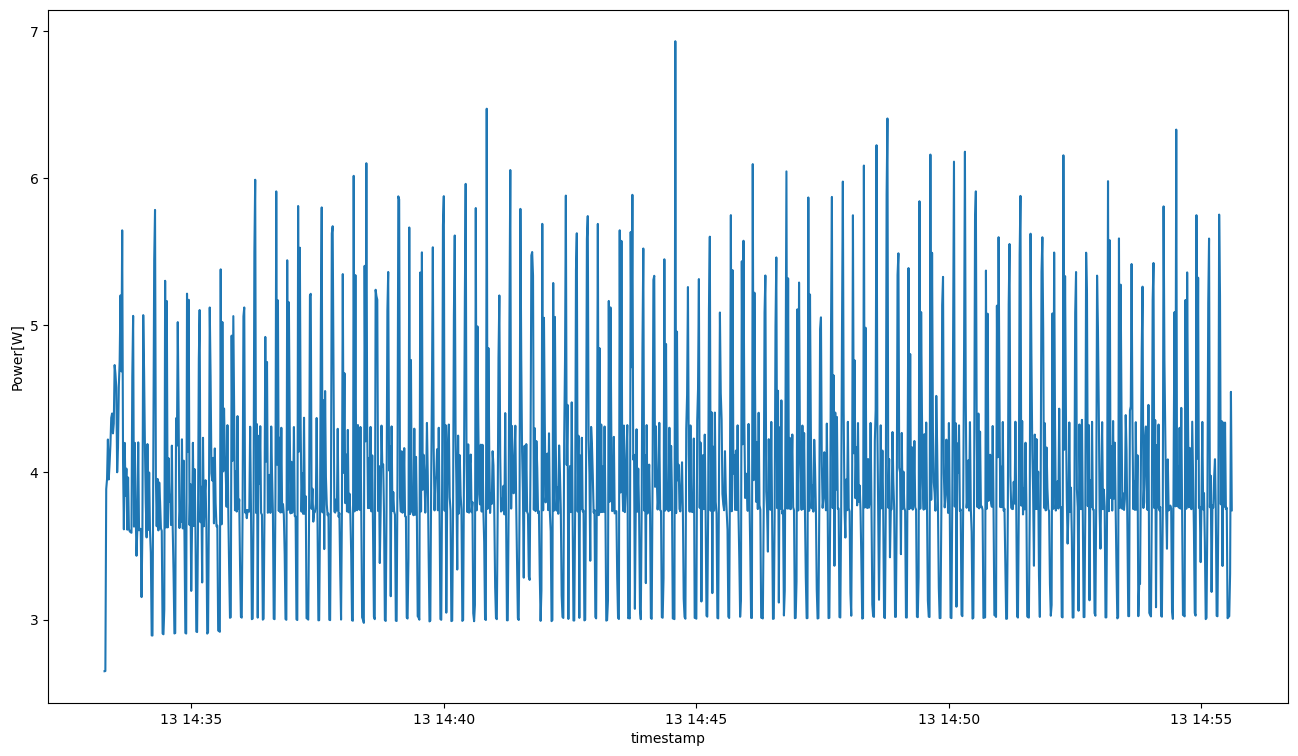

In [49]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=ds_spower.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## Batch Stream Str

In [13]:
batch_folder_path = '../infra/reports/batch_2026-04-13T14:56:06.690568'

### CPU

In [14]:
ds_bcpu = pd.read_csv(f'{batch_folder_path}/cpu.csv')

ds_bcpu['timestamp'] = ds_bcpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
ds_bcpu['cpu_mean']  = ds_bcpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

ds_bcpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1504.000000,1504.000000,1504.000000,1504.000000,1504.000000
mean,10.072806,11.461237,12.325731,10.777926,11.159425
std,18.181910,18.277795,19.031005,18.604686,16.418412
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,3.525000
50%,0.000000,0.000000,0.000000,0.000000,5.700000
75%,14.900000,18.800000,20.800000,17.000000,7.500000
max,77.200000,79.800000,100.000000,75.000000,71.025000


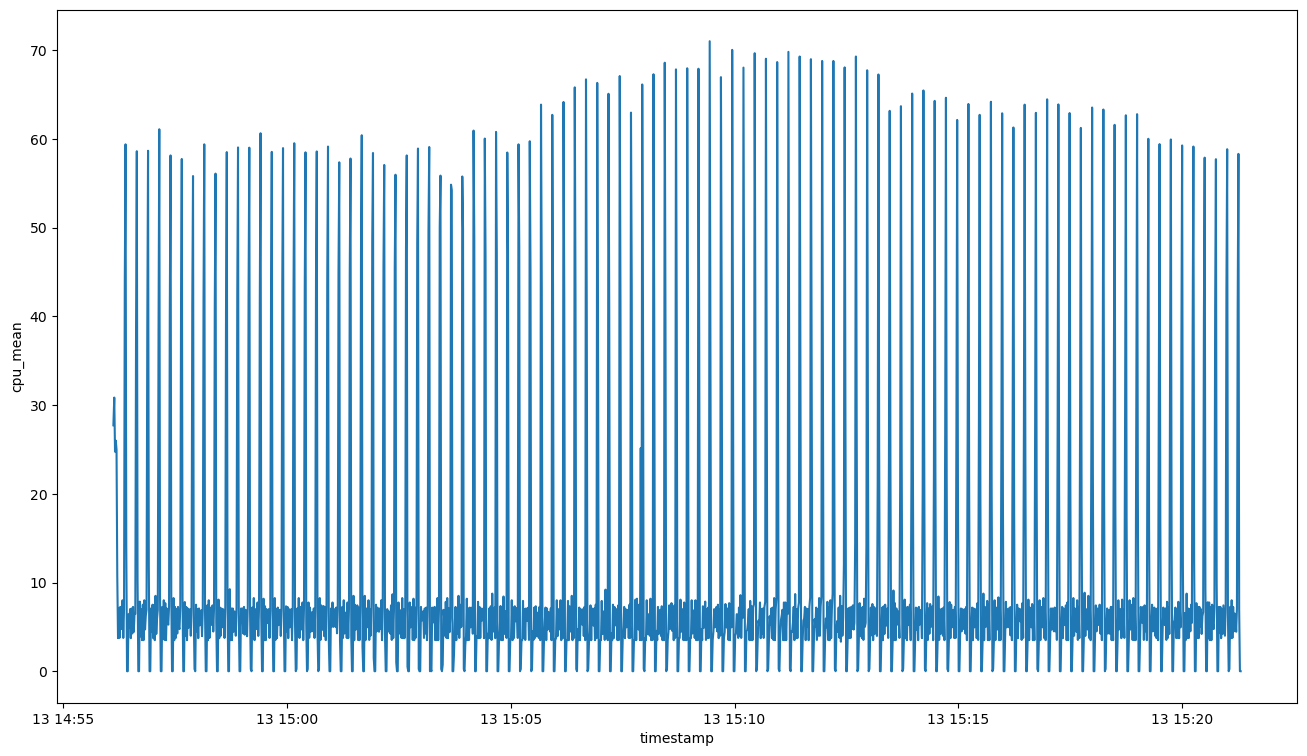

In [15]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=ds_bcpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

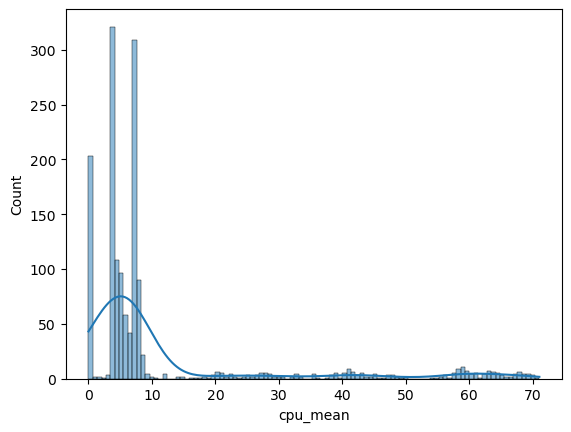

In [39]:
sns.histplot(data=ds_bcpu, x="cpu_mean", kde=True)
plt.show()

### RAM

In [52]:
ds_bram = pd.read_csv(f'{batch_folder_path}/mem.csv')
ds_bram['timestamp'] = ds_bram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
ds_bram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,1.507000e+03,1.507000e+03,1.507000e+03,1507.000000,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03
mean,1.700264e+10,1.507798e+10,1.924664e+09,11.320372,1.423518e+10,2.195368e+09,3.532464e+08,4.093769e+07,9.204424e+08
std,0.000000e+00,1.186983e+08,1.186983e+08,0.699955,1.187298e+08,1.253619e+08,1.184032e+05,6.671650e+04,2.170978e+05
min,1.700264e+10,1.493079e+10,5.307269e+08,3.100000,1.408819e+10,8.103854e+08,3.529769e+08,4.081254e+07,9.201254e+08
25%,1.700264e+10,1.504577e+10,1.926136e+09,11.300000,1.420299e+10,2.187756e+09,3.531735e+08,4.089446e+07,9.203220e+08
50%,1.700264e+10,1.505799e+10,1.944650e+09,11.400000,1.421527e+10,2.225947e+09,3.532063e+08,4.092723e+07,9.203220e+08
75%,1.700264e+10,1.507651e+10,1.956872e+09,11.500000,1.423385e+10,2.227552e+09,3.532227e+08,4.094362e+07,9.203220e+08
max,1.700264e+10,1.647192e+10,2.071855e+09,12.200000,1.562953e+10,2.255585e+09,3.534684e+08,4.105830e+07,9.209610e+08


### Predict

In [18]:
import json

with open(f'{batch_folder_path}/metrics.json') as f:
    batch_data = json.load(f)

load_model_duration = datetime.fromisoformat(batch_data['load_model_final']) - datetime.fromisoformat(batch_data['load_model_start'])

rows = []
for animal, v1 in batch_data['animals'].items():
    row = {
        'pid': batch_data['pid'],
        'load_model_start': datetime.fromisoformat(batch_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(batch_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

ds_bmetrics_v0 = pd.DataFrame.from_dict(rows)[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
ds_bmetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time
0,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,1,2026-04-13 14:56:12.006714,2026-04-13 14:56:21.733494,2026-04-13 14:56:22.373855,2026-04-13 14:56:24.218208,2026-04-13 14:56:24.218309
1,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,2,2026-04-13 14:56:27.220185,2026-04-13 14:56:36.930256,2026-04-13 14:56:37.570166,2026-04-13 14:56:39.272982,2026-04-13 14:56:39.273056
2,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,3,2026-04-13 14:56:42.274470,2026-04-13 14:56:51.990115,2026-04-13 14:56:52.628431,2026-04-13 14:56:54.331037,2026-04-13 14:56:54.331113
3,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,4,2026-04-13 14:56:57.332506,2026-04-13 14:57:07.052004,2026-04-13 14:57:07.691259,2026-04-13 14:57:09.388684,2026-04-13 14:57:09.388758
4,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,5,2026-04-13 14:57:12.390132,2026-04-13 14:57:22.094040,2026-04-13 14:57:22.733626,2026-04-13 14:57:24.435374,2026-04-13 14:57:24.435454


In [19]:
ds_bmetrics_v0['by_animal_lead_time'] = ds_bmetrics_v0['display_time'] - ds_bmetrics_v0['first_image_capture_time']
ds_bmetrics_v0['by_animal_processing_delay'] = ds_bmetrics_v0['weight_prediction_final'] - ds_bmetrics_v0['weight_prediction_start']
ds_bmetrics_v0['by_animal_latency'] = ds_bmetrics_v0['display_time'] - ds_bmetrics_v0['last_image_capture_time']

ds_bmetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,1,2026-04-13 14:56:12.006714,2026-04-13 14:56:21.733494,2026-04-13 14:56:22.373855,2026-04-13 14:56:24.218208,2026-04-13 14:56:24.218309,0 days 00:00:12.211595,0 days 00:00:01.844353,0 days 00:00:02.484815
1,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,2,2026-04-13 14:56:27.220185,2026-04-13 14:56:36.930256,2026-04-13 14:56:37.570166,2026-04-13 14:56:39.272982,2026-04-13 14:56:39.273056,0 days 00:00:12.052871,0 days 00:00:01.702816,0 days 00:00:02.342800
2,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,3,2026-04-13 14:56:42.274470,2026-04-13 14:56:51.990115,2026-04-13 14:56:52.628431,2026-04-13 14:56:54.331037,2026-04-13 14:56:54.331113,0 days 00:00:12.056643,0 days 00:00:01.702606,0 days 00:00:02.340998
3,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,4,2026-04-13 14:56:57.332506,2026-04-13 14:57:07.052004,2026-04-13 14:57:07.691259,2026-04-13 14:57:09.388684,2026-04-13 14:57:09.388758,0 days 00:00:12.056252,0 days 00:00:01.697425,0 days 00:00:02.336754
4,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,5,2026-04-13 14:57:12.390132,2026-04-13 14:57:22.094040,2026-04-13 14:57:22.733626,2026-04-13 14:57:24.435374,2026-04-13 14:57:24.435454,0 days 00:00:12.045322,0 days 00:00:01.701748,0 days 00:00:02.341414


In [20]:
collect_lead_time = ds_bmetrics_v0['display_time'].max() - ds_bmetrics_v0['first_image_capture_time'].min()
qtt = len(ds_bmetrics_v0['animal'].unique())

ds_bmetrics_v0['collect_lead_time'] = collect_lead_time
ds_bmetrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

ds_bmetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,1,2026-04-13 14:56:12.006714,2026-04-13 14:56:21.733494,2026-04-13 14:56:22.373855,2026-04-13 14:56:24.218208,2026-04-13 14:56:24.218309,0 days 00:00:12.211595,0 days 00:00:01.844353,0 days 00:00:02.484815,0 days 00:25:03.219782,239.485938
1,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,2,2026-04-13 14:56:27.220185,2026-04-13 14:56:36.930256,2026-04-13 14:56:37.570166,2026-04-13 14:56:39.272982,2026-04-13 14:56:39.273056,0 days 00:00:12.052871,0 days 00:00:01.702816,0 days 00:00:02.342800,0 days 00:25:03.219782,239.485938
2,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,3,2026-04-13 14:56:42.274470,2026-04-13 14:56:51.990115,2026-04-13 14:56:52.628431,2026-04-13 14:56:54.331037,2026-04-13 14:56:54.331113,0 days 00:00:12.056643,0 days 00:00:01.702606,0 days 00:00:02.340998,0 days 00:25:03.219782,239.485938
3,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,4,2026-04-13 14:56:57.332506,2026-04-13 14:57:07.052004,2026-04-13 14:57:07.691259,2026-04-13 14:57:09.388684,2026-04-13 14:57:09.388758,0 days 00:00:12.056252,0 days 00:00:01.697425,0 days 00:00:02.336754,0 days 00:25:03.219782,239.485938
4,batch_2026-04-13T14:56:06.690568,2026-04-13 14:56:06.694509,2026-04-13 14:56:12.005747,0 days 00:00:05.311238,5,2026-04-13 14:57:12.390132,2026-04-13 14:57:22.094040,2026-04-13 14:57:22.733626,2026-04-13 14:57:24.435374,2026-04-13 14:57:24.435454,0 days 00:00:12.045322,0 days 00:00:01.701748,0 days 00:00:02.341414,0 days 00:25:03.219782,239.485938


### Power

In [47]:
ds_bpower = pd.read_csv(f'{batch_folder_path}/batch.csv')

ds_bpower['timestamp'] = ds_bpower['Datetime'].apply(lambda x: datetime.fromisoformat(x))

ds_bpower.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-13T14:56:02.925395,0.0,5.1078,0.58545,2.9857,2026-04-13 14:56:02.925395
1,2026-04-13T14:56:03.895169,1.0,5.1079,0.58516,2.9843,2026-04-13 14:56:03.895169
2,2026-04-13T14:56:04.915889,2.0,5.1064,0.94048,4.7964,2026-04-13 14:56:04.915889
3,2026-04-13T14:56:05.890284,3.0,5.1078,0.92583,4.7217,2026-04-13 14:56:05.890284
4,2026-04-13T14:56:06.911748,4.0,5.1076,0.98420,5.0194,2026-04-13 14:56:06.911748


In [48]:
ds_bpower = ds_bpower.sort_values('timestamp')

# Time difference in hours
ds_bpower['dt_hours'] = ds_bpower['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
ds_bpower['energy_Wh'] = ds_bpower['Power[W]'] * ds_bpower['dt_hours']

# Total energy
total_energy_Wh = ds_bpower['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.7899371113113611
Total energy (kWh): 0.001789937111311361


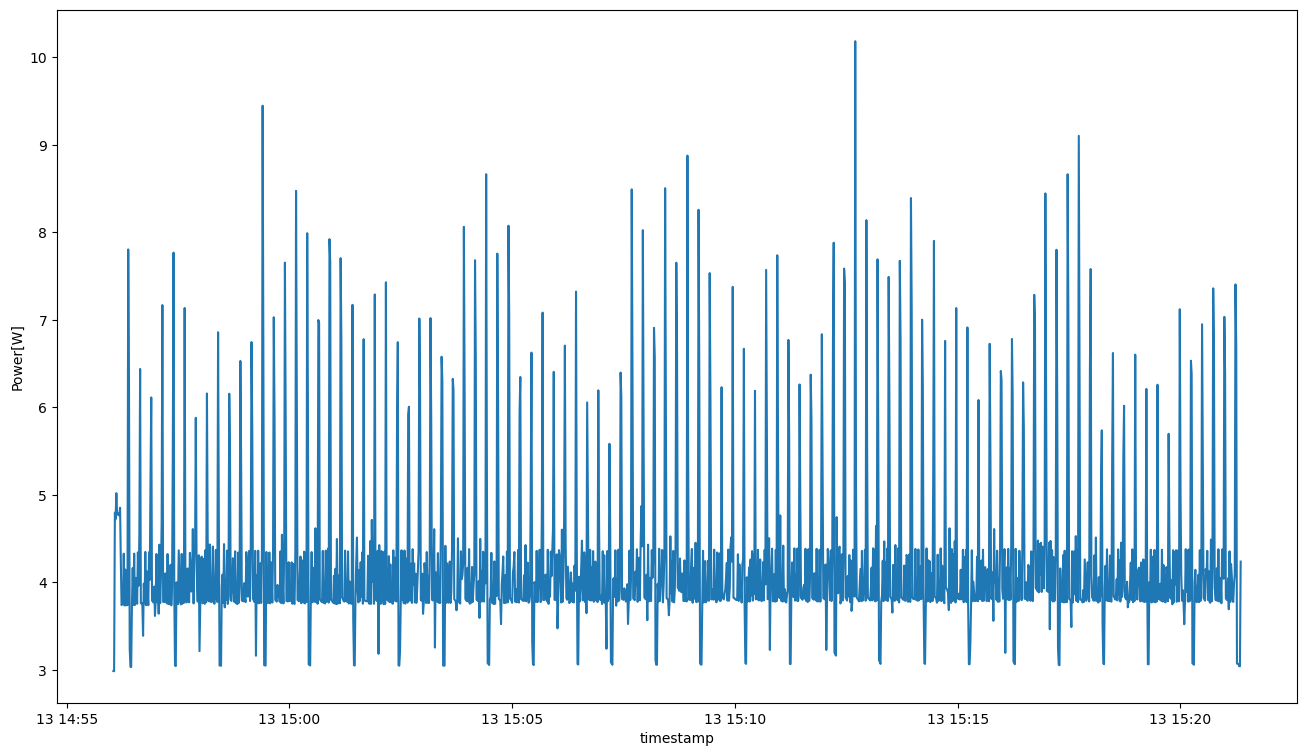

In [50]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=ds_bpower.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## Comparing

### Metrics

In [25]:
ds_smetrics_v1[['by_animal_latency','by_animal_processing_delay','collect_lead_time','mean_throughput']].describe()
# 12 imgs por animal
# 2 suited
# 12 * 100 animais / 21min => 0.95 FPS

,by_animal_latency,by_animal_processing_delay,collect_lead_time,mean_throughput
count,200,200,200,2.000000e+02
mean,0 days 00:00:00.639667660,0 days 00:00:01.748328600,0 days 00:21:54.810564,2.738037e+02
std,0 days 00:00:00.002419666,0 days 00:00:00.008771289,0 days 00:00:00,7.408188e-13
min,0 days 00:00:00.637391,0 days 00:00:01.720014,0 days 00:21:54.810564,2.738037e+02
25%,0 days 00:00:00.638981,0 days 00:00:01.744941,0 days 00:21:54.810564,2.738037e+02
50%,0 days 00:00:00.639412500,0 days 00:00:01.748962,0 days 00:21:54.810564,2.738037e+02
75%,0 days 00:00:00.639983,0 days 00:00:01.753666500,0 days 00:21:54.810564,2.738037e+02
max,0 days 00:00:00.662078,0 days 00:00:01.765784,0 days 00:21:54.810564,2.738037e+02


In [40]:
ds_smetrics_v1['by_animal_processing_delay'].sum()

Timedelta('0 days 00:05:49.665720')

In [26]:
ds_bmetrics_v0[['by_animal_latency','by_animal_processing_delay','collect_lead_time','mean_throughput']].describe()
# 16 imgs por animal
# 5 suited
# 16 * 100 animais / 25min => 1.06 FPS

,by_animal_latency,by_animal_processing_delay,collect_lead_time,mean_throughput
count,100,100,100,1.000000e+02
mean,0 days 00:00:02.343364350,0 days 00:00:01.703732480,0 days 00:25:03.219782,2.394859e+02
std,0 days 00:00:00.017283244,0 days 00:00:00.017181984,0 days 00:00:00,2.856489e-13
min,0 days 00:00:02.311359,0 days 00:00:01.672786,0 days 00:25:03.219782,2.394859e+02
25%,0 days 00:00:02.337611,0 days 00:00:01.697163500,0 days 00:25:03.219782,2.394859e+02
50%,0 days 00:00:02.342907,0 days 00:00:01.703156,0 days 00:25:03.219782,2.394859e+02
75%,0 days 00:00:02.348470250,0 days 00:00:01.708920250,0 days 00:25:03.219782,2.394859e+02
max,0 days 00:00:02.484815,0 days 00:00:01.844353,0 days 00:25:03.219782,2.394859e+02


In [42]:
ds_bmetrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:50.373248')

### CPU

In [27]:
ds_scpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1318.000000,1318.000000,1318.000000,1318.000000,1318.000000
mean,7.908574,8.978073,10.960395,7.491351,8.834598
std,13.055917,14.663132,14.370896,12.788021,9.395413
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,3.500000
50%,0.000000,0.000000,1.000000,0.000000,5.625000
75%,14.000000,15.000000,18.950000,13.900000,9.112500
max,79.000000,99.000000,83.200000,80.200000,37.325000


In [28]:
ds_bcpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1504.000000,1504.000000,1504.000000,1504.000000,1504.000000
mean,10.072806,11.461237,12.325731,10.777926,11.159425
std,18.181910,18.277795,19.031005,18.604686,16.418412
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,3.525000
50%,0.000000,0.000000,0.000000,0.000000,5.700000
75%,14.900000,18.800000,20.800000,17.000000,7.500000
max,77.200000,79.800000,100.000000,75.000000,71.025000


### RAM

In [29]:
ds_sram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,1.321000e+03,1.321000e+03,1.321000e+03,1321.000000,1.321000e+03,1.321000e+03,1.321000e+03,1.321000e+03,1.321000e+03
mean,1.700264e+10,1.603883e+10,9.638177e+08,5.667827,1.524300e+10,1.170260e+09,3.517118e+08,4.059849e+07,8.736583e+08
std,0.000000e+00,5.146686e+07,5.146686e+07,0.302643,7.018956e+07,6.812936e+07,9.275831e+06,1.304409e+05,3.738566e+07
min,1.700264e+10,1.578831e+10,5.528945e+08,3.300000,1.500756e+10,7.320207e+08,1.927414e+08,4.043571e+07,6.804931e+08
25%,1.700264e+10,1.599568e+10,9.246638e+08,5.400000,1.519791e+10,1.102332e+09,3.519775e+08,4.046848e+07,8.452178e+08
50%,1.700264e+10,1.605313e+10,9.495183e+08,5.600000,1.524430e+10,1.174847e+09,3.521577e+08,4.064870e+07,8.453816e+08
75%,1.700264e+10,1.607798e+10,1.006961e+09,5.900000,1.530112e+10,1.212580e+09,3.526984e+08,4.073062e+07,9.180938e+08
max,1.700264e+10,1.644975e+10,1.214333e+09,7.100000,1.584721e+10,1.301938e+09,3.527148e+08,4.074701e+07,9.182577e+08


In [30]:
ds_bram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,1.507000e+03,1.507000e+03,1.507000e+03,1507.000000,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03
mean,1.700264e+10,1.507798e+10,1.924664e+09,11.320372,1.423518e+10,2.195368e+09,3.532464e+08,4.093769e+07,9.204424e+08
std,0.000000e+00,1.186983e+08,1.186983e+08,0.699955,1.187298e+08,1.253619e+08,1.184032e+05,6.671650e+04,2.170978e+05
min,1.700264e+10,1.493079e+10,5.307269e+08,3.100000,1.408819e+10,8.103854e+08,3.529769e+08,4.081254e+07,9.201254e+08
25%,1.700264e+10,1.504577e+10,1.926136e+09,11.300000,1.420299e+10,2.187756e+09,3.531735e+08,4.089446e+07,9.203220e+08
50%,1.700264e+10,1.505799e+10,1.944650e+09,11.400000,1.421527e+10,2.225947e+09,3.532063e+08,4.092723e+07,9.203220e+08
75%,1.700264e+10,1.507651e+10,1.956872e+09,11.500000,1.423385e+10,2.227552e+09,3.532227e+08,4.094362e+07,9.203220e+08
max,1.700264e+10,1.647192e+10,2.071855e+09,12.200000,1.562953e+10,2.255585e+09,3.534684e+08,4.105830e+07,9.209610e+08


### Power

In [37]:
ds_spower.describe()

,Time[S],Volt[V],Current[A],Power[W]
count,1340.000000,1340.000000,1340.000000,1340.000000
mean,669.568806,5.108339,0.778787,3.972572
std,387.021061,0.002340,0.143281,0.731118
min,0.000000,5.087000,0.519400,2.648900
25%,334.750000,5.108000,0.725635,3.700675
50%,669.600000,5.108500,0.740185,3.776200
75%,1004.350000,5.109200,0.840562,4.286825
max,1339.200000,5.118100,1.358670,6.929200


In [38]:
ds_bpower.describe()

,Time[S],Volt[V],Current[A],Power[W]
count,1519.000000,1519.000000,1519.000000,1519.000000
mean,759.117051,5.107922,0.831993,4.243775
std,438.710770,0.004108,0.192911,0.983332
min,0.000000,5.073700,0.585160,2.984300
25%,379.600000,5.107500,0.741725,3.784000
50%,759.100000,5.108000,0.762090,3.886600
75%,1138.700000,5.108600,0.850415,4.337050
max,1518.200000,5.133100,2.000770,10.183900
